# BiLSTM-MTRAN-TCN Prediction Pipeline

This notebook implements section 4.1 from the economic-signal PDF and the BiLSTM/improved-Transformer reference paper.

Architecture mapping:

- Positional encoding injects time-step order into the 3-D financial tensor.
- BiLSTM extracts bidirectional local sequence dependencies.
- MTRAN is implemented as a normalized Transformer encoder over the BiLSTM sequence representation.
- TCN uses causal dilated 1-D convolution blocks to decode temporal patterns before the dense output head.

The notebook runs training through a Python subprocess so PyTorch does not need to load inside the Jupyter kernel.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from benchmark_utils import INDEX_TICKERS
from plot_results import plot_price_predictions, plot_tensor_surface

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [2]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
HORIZON = 1
TOP_K = 16
EPOCHS = 80

RUN_TRAINING = True
OUTPUT_DIR = Path(f"outputs_bilstm_mtran_tcn_h{HORIZON}")
PLOTS_DIR = Path(f"plots_bilstm_mtran_tcn_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## Train BiLSTM-MTRAN-TCN

In [3]:
if RUN_TRAINING:
    cmd = [
        sys.executable, str(SRC_DIR / "hybrid_bilstm_mtran_tcn.py"),
        "--start", START, "--end", END,
        "--train-end", TRAIN_END, "--test-start", TEST_START, "--test-end", TEST_END,
        "--lookback", str(LOOKBACK), "--horizon", str(HORIZON), "--top-k", str(TOP_K),
        "--epochs", str(EPOCHS), "--output-dir", str(OUTPUT_DIR),
    ]
    print(" ".join(cmd))
    completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
    print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)

summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
summary


c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\python.exe c:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\src\hybrid_bilstm_mtran_tcn.py --start 2010-01-01 --end 2026-06-01 --train-end 2025-12-31 --test-start 2026-01-01 --test-end 2026-05-31 --lookback 30 --horizon 1 --top-k 16 --epochs 80 --output-dir outputs_bilstm_mtran_tcn_h1
Running BiLSTM-MTRAN-TCN Nasdaq (^IXIC)...
Nasdaq: RMSE=263.16, MAE=208.97, MAPE=0.89%
Running BiLSTM-MTRAN-TCN SP500 (^GSPC)...
SP500: RMSE=58.17, MAE=44.96, MAPE=0.65%
Running BiLSTM-MTRAN-TCN SOX (^SOX)...
SOX: RMSE=236.94, MAE=183.03, MAPE=2.01%
Saved outputs to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\outputs_bilstm_mtran_tcn_h1



,index,ticker,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,samples,train_samples,model,features,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,263.164215,208.967194,0.894019,265.655273,212.978867,0.937703,1.883601,59.803922,102,3935,BiLSTM-MTRAN-TCN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",0.361298,0.355573
1,SP500,^GSPC,58.170971,44.964931,0.652381,58.252670,44.949280,0.140250,-0.034821,56.862745,102,3935,BiLSTM-MTRAN-TCN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",0.353630,0.281542
2,SOX,^SOX,236.937332,183.030960,2.007626,232.848175,180.839233,-1.756147,-1.211975,50.980392,102,3935,BiLSTM-MTRAN-TCN,"['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_...",0.355279,0.485072


## Benchmark Summary

In [4]:
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct",
    "direction_accuracy_pct", "final_train_loss", "final_val_loss",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,BiLSTM-MTRAN-TCN,102,3935,263.164215,208.967194,0.894019,265.655273,212.978867,0.937703,1.883601,59.803922,0.361298,0.355573
1,SP500,^GSPC,BiLSTM-MTRAN-TCN,102,3935,58.170971,44.964931,0.652381,58.252670,44.949280,0.140250,-0.034821,56.862745,0.353630,0.281542
2,SOX,^SOX,BiLSTM-MTRAN-TCN,102,3935,236.937332,183.030960,2.007626,232.848175,180.839233,-1.756147,-1.211975,50.980392,0.355279,0.485072


## Feature Ranking

In [5]:
feature_ic = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_ic.csv").head(TOP_K)
    for index_name in summary["index"]
}
feature_ic["Nasdaq"]


,feature,ic,abs_ic
0,Low,0.999640,0.999640
1,High,0.999632,0.999632
2,Open,0.999549,0.999549
3,MA_5,0.999406,0.999406
4,EMA_12,0.999116,0.999116
5,MA_10,0.999029,0.999029
6,EMA_26,0.998329,0.998329
7,MA_20,0.998256,0.998256
8,MA_60,0.995249,0.995249
9,Volume,0.882157,0.882157


## Generate Plots

In [6]:
for index_name in summary["index"]:
    plot_tensor_surface(
        index_name=index_name,
        raw_path=OUTPUT_DIR / f"{index_name}_raw.csv",
        feature_ic_path=OUTPUT_DIR / f"{index_name}_feature_ic.csv",
        output_path=PLOTS_DIR / f"{index_name}_tensor_3d.png",
        lookback=LOOKBACK, horizon=HORIZON, top_k=TOP_K,
        train_end=TRAIN_END, test_start=TEST_START, test_end=TEST_END,
    )
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )
print(f"Saved plots to {PLOTS_DIR.resolve()}")


Saved plots to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\plots_bilstm_mtran_tcn_h1


## Display Example Plot

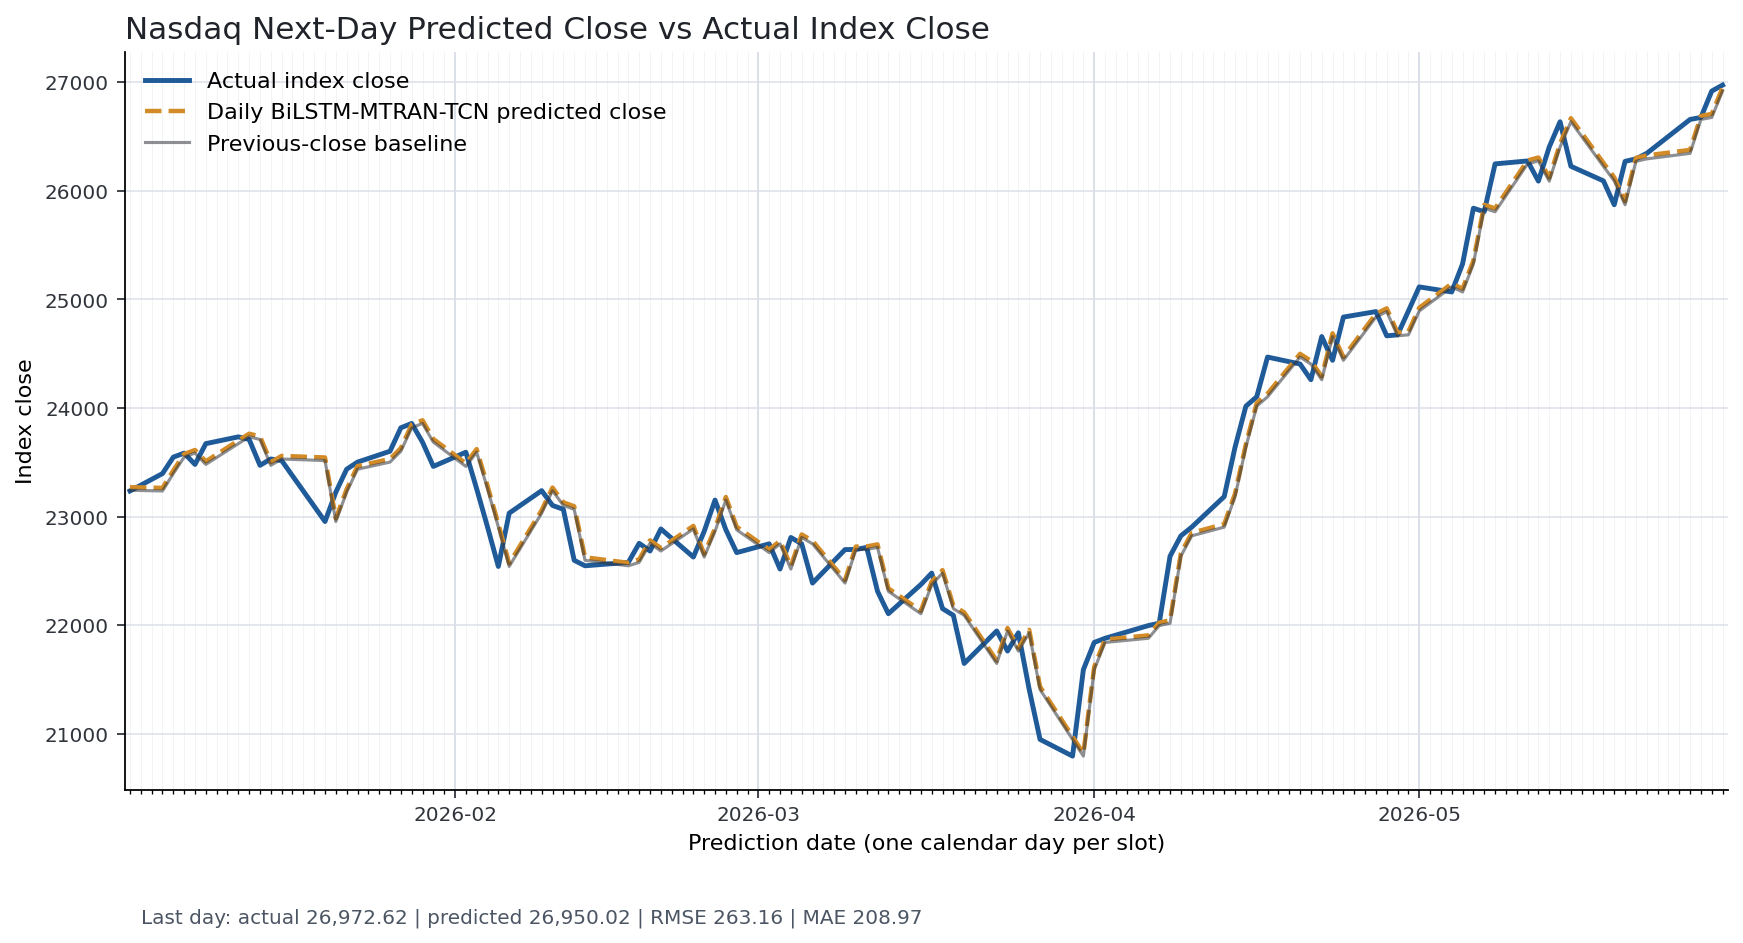

In [7]:
example_plot = PLOTS_DIR / "Nasdaq_price_prediction.png"
if example_plot.exists():
    display(Image(filename=str(example_plot)))
else:
    print(f"Plot not found: {example_plot}")
